2026-02-21 05:07:09.613561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771650430.099464      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771650430.220004      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771650431.191600      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771650431.191646      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771650431.191649      25 computation_placer.cc:177] computation placer alr

Loading Training Set:
Found 27188 images belonging to 4 classes.
Loading Validation Set:
Found 6796 images belonging to 4 classes.
Loading Unseen Test Set:
Found 6400 images belonging to 4 classes.

⚖️ Calculating Class Weights to fix Imbalance...
MildDemented weight: 0.9482
ModerateDemented weight: 1.3142
NonDemented weight: 0.8850
VeryMildDemented weight: 0.9482


I0000 00:00:1771650483.836572      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771650483.843048      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Starting VGG16 Training for 50 Epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1771650488.618702      92 service.cc:152] XLA service 0x79800000d620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771650488.618736      92 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771650488.618741      92 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771650489.216425      92 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/850 ━━━━━━━━━━━━━━━━━━━━ 3:37:47 15s/step - accuracy: 0.2812 - loss: 16.0441

I0000 00:00:1771650502.135466      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.5254 - loss: 2.2576
Epoch 1: val_accuracy improved from -inf to 0.75309, saving model to /kaggle/working/best_vgg16_model.keras
850/850 ━━━━━━━━━━━━━━━━━━━━ 315s 353ms/step - accuracy: 0.5255 - loss: 2.2563 - val_accuracy: 0.7531 - val_loss: 0.5660
Epoch 2/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7110 - loss: 0.5870
Epoch 2: val_accuracy improved from 0.75309 to 0.80503, saving model to /kaggle/working/best_vgg16_model.keras
850/850 ━━━━━━━━━━━━━━━━━━━━ 189s 223ms/step - accuracy: 0.7110 - loss: 0.5870 - val_accuracy: 0.8050 - val_loss: 0.4613
Epoch 3/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7803 - loss: 0.4633
Epoch 3: val_accuracy improved from 0.80503 to 0.85079, saving model to /kaggle/working/best_vgg16_model.keras
850/850 ━━━━━━━━━━━━━━━━━━━━ 191s 224ms/step - accuracy: 0.7803 - loss: 0.4633 - val_accuracy: 0.8508 - val_loss: 0.3629
Epoch 4/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step 

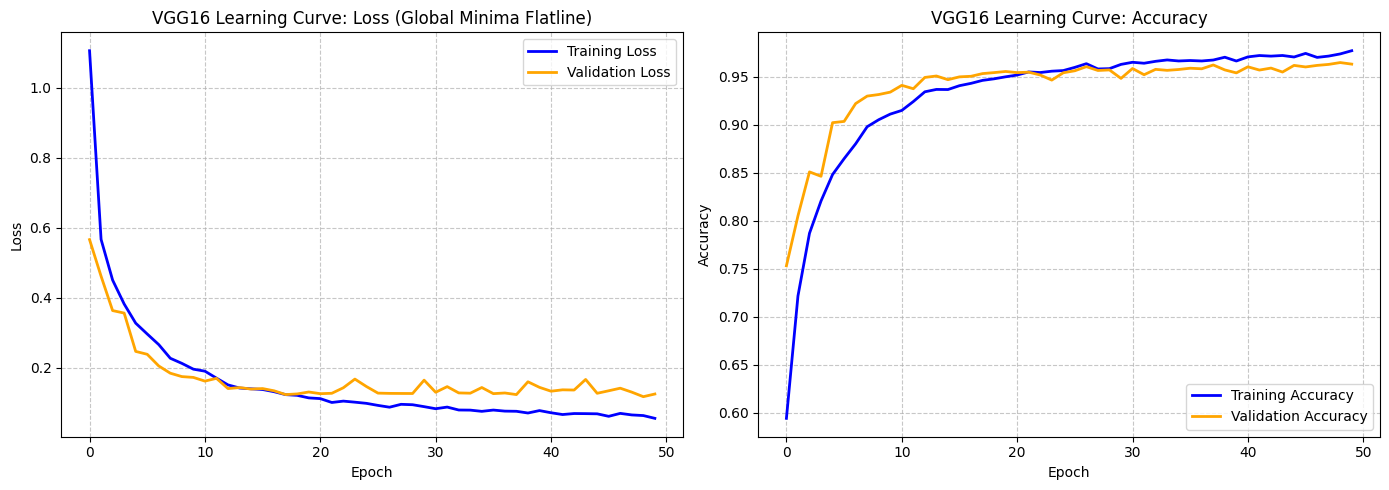


🧪 Evaluating on Unseen Test Set...
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step
✅ Testing Time: 41.65 seconds

📊 Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.99      1.00      0.99       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       0.95      0.99      0.97      3200
VeryMildDemented       0.98      0.93      0.96      2240

        accuracy                           0.97      6400
       macro avg       0.98      0.98      0.98      6400
    weighted avg       0.97      0.97      0.97      6400


🎯 Class-wise Accuracies:
MildDemented: 0.9955
ModerateDemented: 1.0000
NonDemented: 0.9875
VeryMildDemented: 0.9330


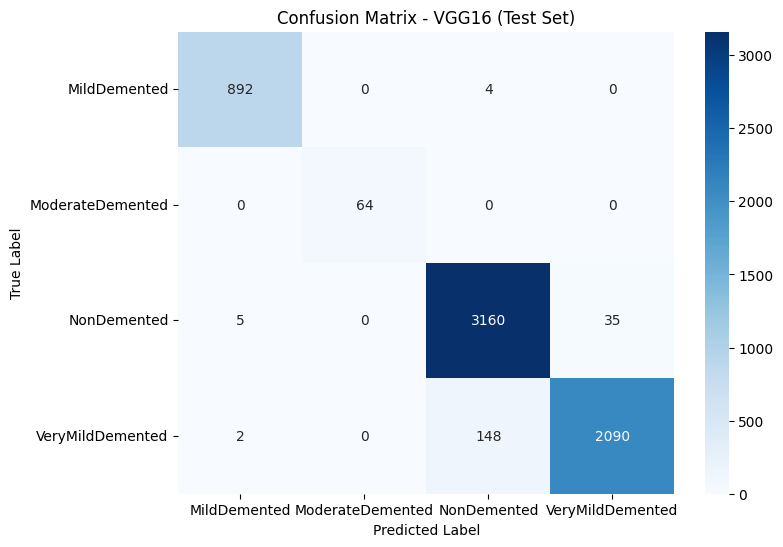

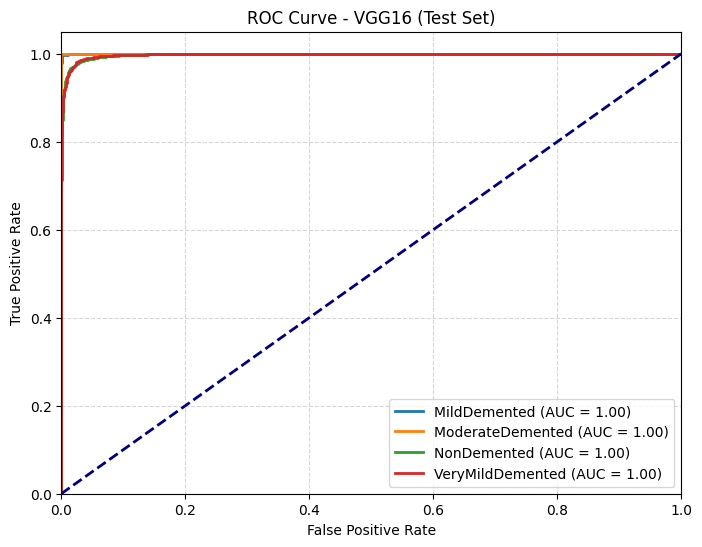


💾 Saved VGG16 correctness array for the final paired t-test.


In [1]:
import os
# Hide standard TensorFlow warnings for a cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# 1. Dataset Preparation (Research-Grade 3-Way Split)
# ==========================================
# Using the exact Kaggle paths
TRAIN_DIR = '/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset-v2/data/train'
TEST_DIR = '/kaggle/input/datasets/uraninjo/augmented-alzheimer-mri-dataset-v2/data/val' 

BATCH_SIZE = 32
IMG_SIZE = (224, 224) 
EPOCHS = 50 

# Generator for Training & Validation (80/20 split from the train folder)
train_val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    validation_split=0.2 
)

# 1. True Training Set
print("Loading Training Set:")
train_gen = train_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

# 2. True Validation Set (Used to save the best model during training)
print("Loading Validation Set:")
val_gen = train_val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

# 3. Unseen Test Set (Used purely for final evaluation)
print("Loading Unseen Test Set:")
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False 
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_NAMES = list(train_gen.class_indices.keys())

# ==========================================
# 2. Fixing Class Imbalance (Class Weights)
# ==========================================
print("\n⚖️ Calculating Class Weights to fix Imbalance...")
train_classes = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights_dict = dict(enumerate(class_weights_array))

for i, weight in class_weights_dict.items():
    print(f"{CLASS_NAMES[i]} weight: {weight:.4f}")

# ==========================================
# 3. Transfer Learning: VGG16 Model
# ==========================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze initial pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4. Training
# ==========================================
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_vgg16_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

print(f"\n🚀 Starting VGG16 Training for {EPOCHS} Epochs...")
start_train_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen, # Validating against the true validation set
    epochs=EPOCHS,
    class_weight=class_weights_dict, # Applying the mathematical weights
    callbacks=[checkpoint] 
)

end_train_time = time.time()
print(f"\n✅ Total Training Time: {(end_train_time - start_train_time) / 60:.2f} minutes")

# ==========================================
# 5. Plotting Learning Curves (Showing the Flatline)
# ==========================================
plt.figure(figsize=(14, 5))

# Plot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('VGG16 Learning Curve: Loss (Global Minima Flatline)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('VGG16 Learning Curve: Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_learning_curves.png', dpi=300)
plt.show()

# ==========================================
# 6. Testing & Evaluation on Unseen Test Set
# ==========================================
print("\n🧪 Evaluating on Unseen Test Set...")
start_test_time = time.time()

model.load_weights('/kaggle/working/best_vgg16_model.keras')
y_pred_probs = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

end_test_time = time.time()
print(f"✅ Testing Time: {end_test_time - start_test_time:.2f} seconds")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_classes)
class_accuracies = cm.diagonal() / cm.sum(axis=1)

print("\n🎯 Class-wise Accuracies:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name}: {class_accuracies[i]:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - VGG16 (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('/kaggle/working/vgg16_confusion_matrix.png', dpi=300)
plt.show()

# --- ROC Curve & AUC ---
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - VGG16 (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/kaggle/working/vgg16_roc_curve.png', dpi=300)
plt.show()

# ==========================================
# 7. Save Correctness for Paired T-Test
# ==========================================
vgg16_correctness = (y_true == y_pred_classes).astype(int)
np.save('/kaggle/working/vgg16_correctness.npy', vgg16_correctness)
print("\n💾 Saved VGG16 correctness array for the final paired t-test.")
